# Tech Salary Trends Analysis (2020–2025)


## Dataset Overview

- **Total Entries:** 151,445  
- **Total Columns:** 11  
- **Time Span:** 2020 to 2025  
- **Includes:** Job titles, experience levels, employment types, salary data, geographical and remote work indicators.

---

## Column Descriptions

| Column | Description |
|--------|-------------|
| `work_year` | Year the salary was paid |
| `experience_level` | Job experience level: <br> - `EN`: Entry-level / Junior <br> - `MI`: Mid-level / Intermediate <br> - `SE`: Senior-level / Expert <br> - `EX`: Executive-level / Director |
| `employment_type` | Type of employment: <br> - `PT`: Part-time <br> - `FT`: Full-time <br> - `CT`: Contract <br> - `FL`: Freelance |
| `job_title` | Role or position held |
| `salary` | Total gross salary paid |
| `salary_currency` | Currency of the salary (ISO 4217 code) |
| `salary_in_usd` | Converted salary in USD (based on average yearly FX rate from fxdata.foorilla.com) |
| `employee_residence` | Primary country of residence (ISO 3166 code) |
| `remote_ratio` | Remote work percentage: <br> - `0`: No remote (less than 20%) <br> - `50`: Partially remote <br> - `100`: Fully remote (more than 80%) |
| `company_location` | Country of the employer's headquarters (ISO 3166 code) |
| `company_size` | Company size: <br> - `S`: Small (< 50 employees) <br> - `M`: Medium (50–250 employees) <br> - `L`: Large (> 250 employees) |

---



In [ ]:
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.svm import SVR


import plotly.io as pio
pio.templates.default = "plotly_white"

warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.0 MB/s eta 0:00:00


## Data Loading and Initial Exploration
Let's load our dataset and take a first look:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset
df = pd.read_csv('ds_salaries.csv')

# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

Dataset Shape: (607, 12)

Memory Usage: 0.06 MB

First few rows:


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


### Dataset Information

In [ ]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


### Statistical Summary

In [ ]:
# Statistical summary of numerical columns
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,607.000000,303.000000,175.370085,0.000000,151.500000,303.000000,454.500000,606.000000
work_year,607.000000,2021.405272,0.692133,2020.000000,2021.000000,2022.000000,2022.000000,2022.000000
salary,607.000000,324000.062603,1544357.486636,4000.000000,70000.000000,115000.000000,165000.000000,30400000.000000
salary_in_usd,607.000000,112297.869852,70957.259411,2859.000000,62726.000000,101570.000000,150000.000000,600000.000000
remote_ratio,607.000000,70.922570,40.709130,0.000000,50.000000,100.000000,100.000000,100.000000


### Check for Missing Values

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

print("Missing values check:")
missing_df[missing_df['Missing Values'] > 0]

Missing values check:


,Missing Values,Percentage


> *Great! We have a clean dataset with no missing values. Let's proceed with our exploration.*

## Exploratory Data Analysis
> ### 1. Salary Distribution

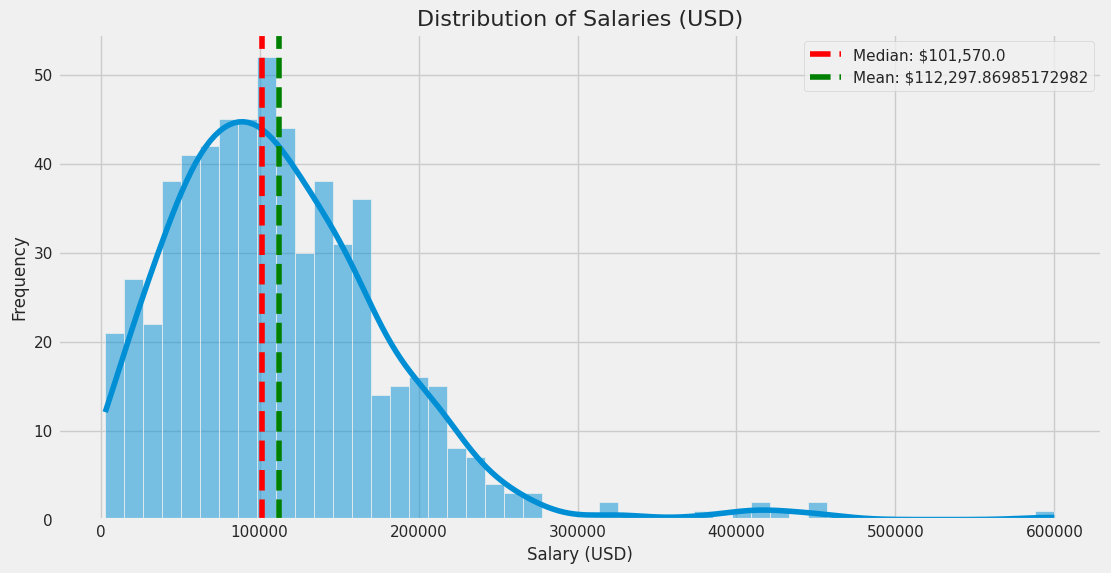

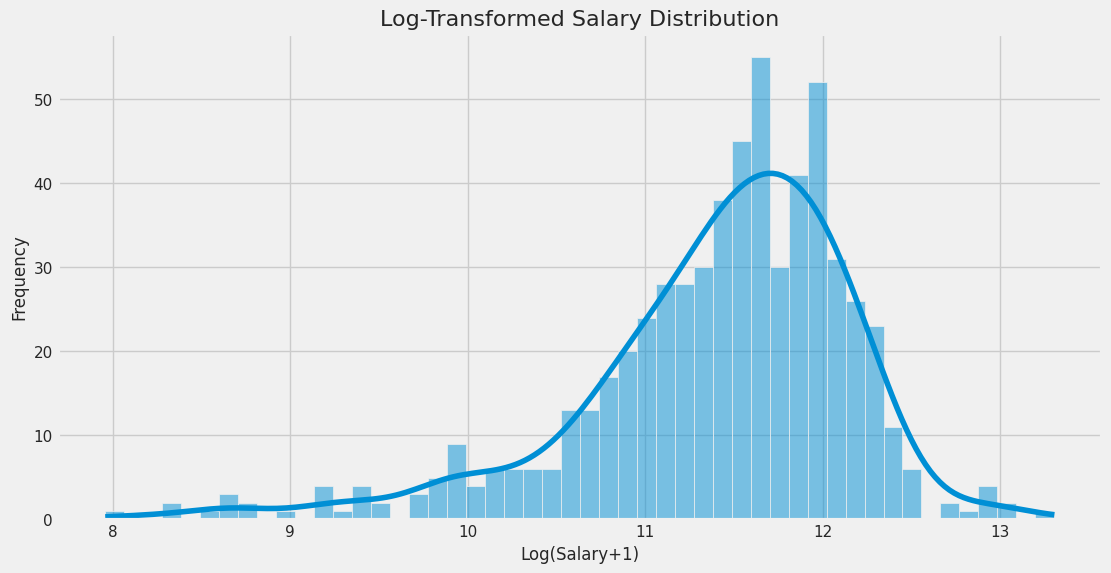

In [ ]:
# Distribution of salaries in USD
plt.figure(figsize=(12, 6))
sns.histplot(df['salary_in_usd'], kde=True, bins=50)
plt.title('Distribution of Salaries (USD)', fontsize=16)
plt.xlabel('Salary (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['salary_in_usd'].median(), color='red', linestyle='--', label=f'Median: ${df["salary_in_usd"].median():,}')
plt.axvline(df['salary_in_usd'].mean(), color='green', linestyle='--', label=f'Mean: ${df["salary_in_usd"].mean():,}')
plt.legend()
plt.show()

# Log-transformed salary distribution (to handle skewness)
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df['salary_in_usd']), kde=True, bins=50)
plt.title('Log-Transformed Salary Distribution', fontsize=16)
plt.xlabel('Log(Salary+1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

> *The salary distribution is right-skewed, with a significant number of high-paying outliers. This is typical for salary data. The log transformation gives us a more normal distribution, which will be useful for modeling.*

### 2. Salary Trends Over Time

In [ ]:
# Yearly salary trends
yearly_stats = df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'std']).reset_index()

fig = px.line(yearly_stats, x='work_year', y=['mean', 'median'],
              title='Data Science Salary Trends (2020-2025)',
              labels={'value': 'Salary (USD)', 'work_year': 'Year', 'variable': 'Metric'},
              template='plotly_white')

fig.update_layout(legend_title_text='', hovermode='x unified',
                 width=900, height=500)

# Add range for standard deviation
fig.add_trace(go.Scatter(
    x=np.concatenate([yearly_stats['work_year'], yearly_stats['work_year'][::-1]]),
    y=np.concatenate([yearly_stats['mean'] + yearly_stats['std'],
                     (yearly_stats['mean'] - yearly_stats['std'])[::-1]]),
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Standard Deviation'
))

fig.show()

> *We can observe a steady increase in both mean and median salaries from 2020 to 2025, with the gap between them widening slightly, indicating increasing inequality in the field.*

### 3. Experience Level Analysis


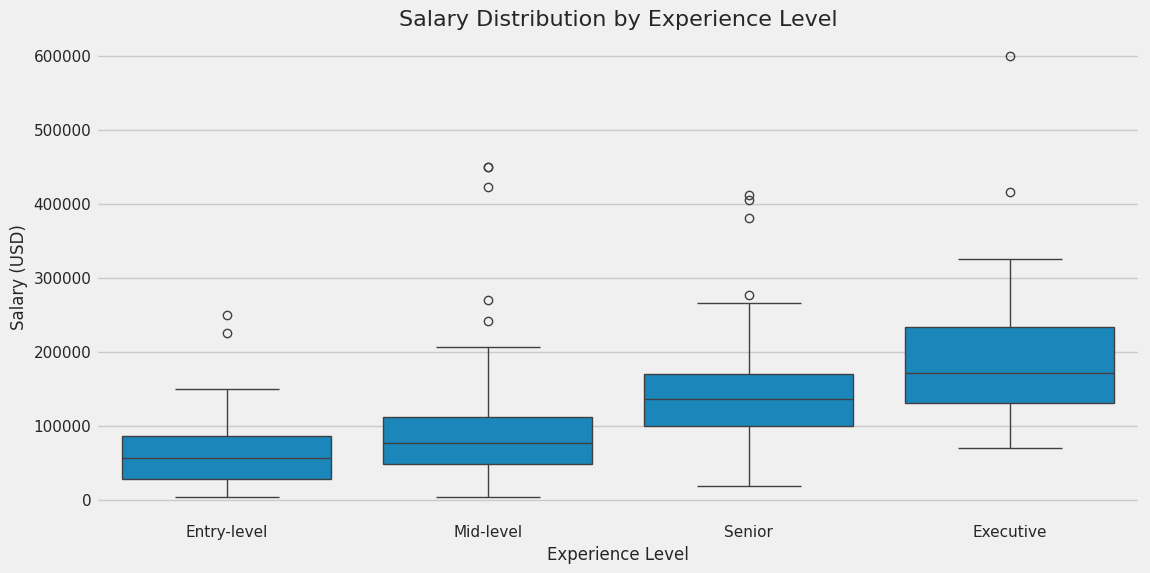

In [ ]:
# Experience level salary comparison
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=df, order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary Distribution by Experience Level', fontsize=16)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Entry-level', 'Mid-level', 'Senior', 'Executive'])
plt.show()

# Mean salary by experience level over time
exp_time = df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().reset_index()
exp_time['experience_level'] = exp_time['experience_level'].replace({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.line(exp_time, x='work_year', y='salary_in_usd', color='experience_level',
             title='Salary Trends by Experience Level (2020-2025)',
             labels={'salary_in_usd': 'Average Salary (USD)', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

> *As expected, experience level has a significant impact on salary, with executives earning substantially more than other levels. The growth rate for executive salaries appears to be steeper, indicating increasing premiums for leadership roles.*

### 4. Job Title Analysis


Distribution of top job titles:
job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Director of Data Science        7
AI Scientist                    7
Principal Data Scientist        7
Data Science Consultant         7
Data Analytics Manager          7
BI Data Analyst                 6
Name: count, dtype: int64


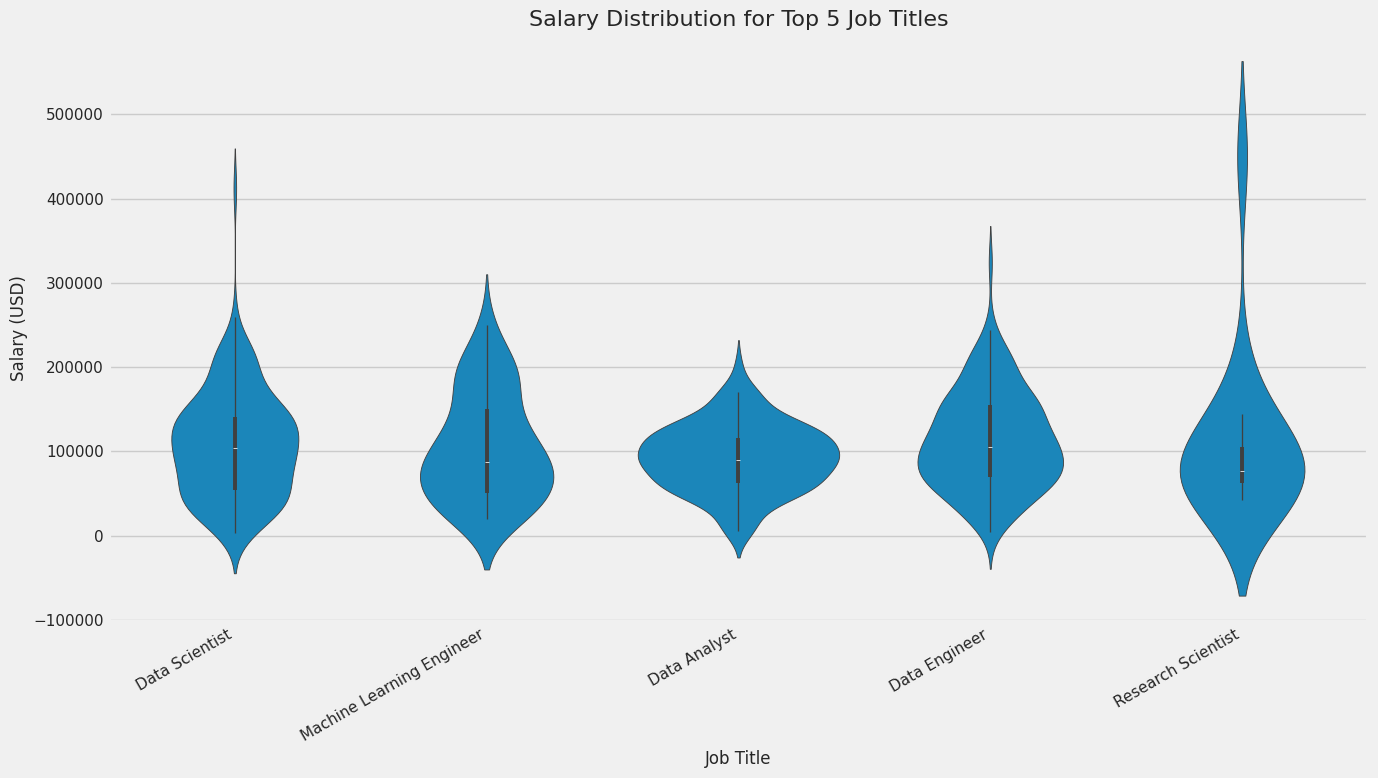

In [ ]:
# Top 15 job titles by count
top_jobs = df['job_title'].value_counts().head(15)
print("Distribution of top job titles:")
print(top_jobs)

# Mean salary for top job titles
top_jobs_salary = df[df['job_title'].isin(top_jobs.index)].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

fig = px.bar(x=top_jobs_salary.index, y=top_jobs_salary.values,
            labels={'x': 'Job Title', 'y': 'Average Salary (USD)'},
            title='Average Salary by Top Job Titles',
            color=top_jobs_salary.values, color_continuous_scale='Viridis')

fig.update_layout(xaxis_tickangle=-45, width=1000, height=600)
fig.show()

# Salary distribution for top 5 job titles
plt.figure(figsize=(14, 8))
top5_jobs = top_jobs.index[:5]
sns.violinplot(x='job_title', y='salary_in_usd', data=df[df['job_title'].isin(top5_jobs)])
plt.title('Salary Distribution for Top 5 Job Titles', fontsize=16)
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

> *Among the most common job titles, Machine Learning Engineers and Research Scientists tend to command the highest salaries, while Data Analysts typically earn less. Software Engineers show the widest salary distribution, reflecting the diverse range of roles under this title..*

### 5. Geographical Analysis


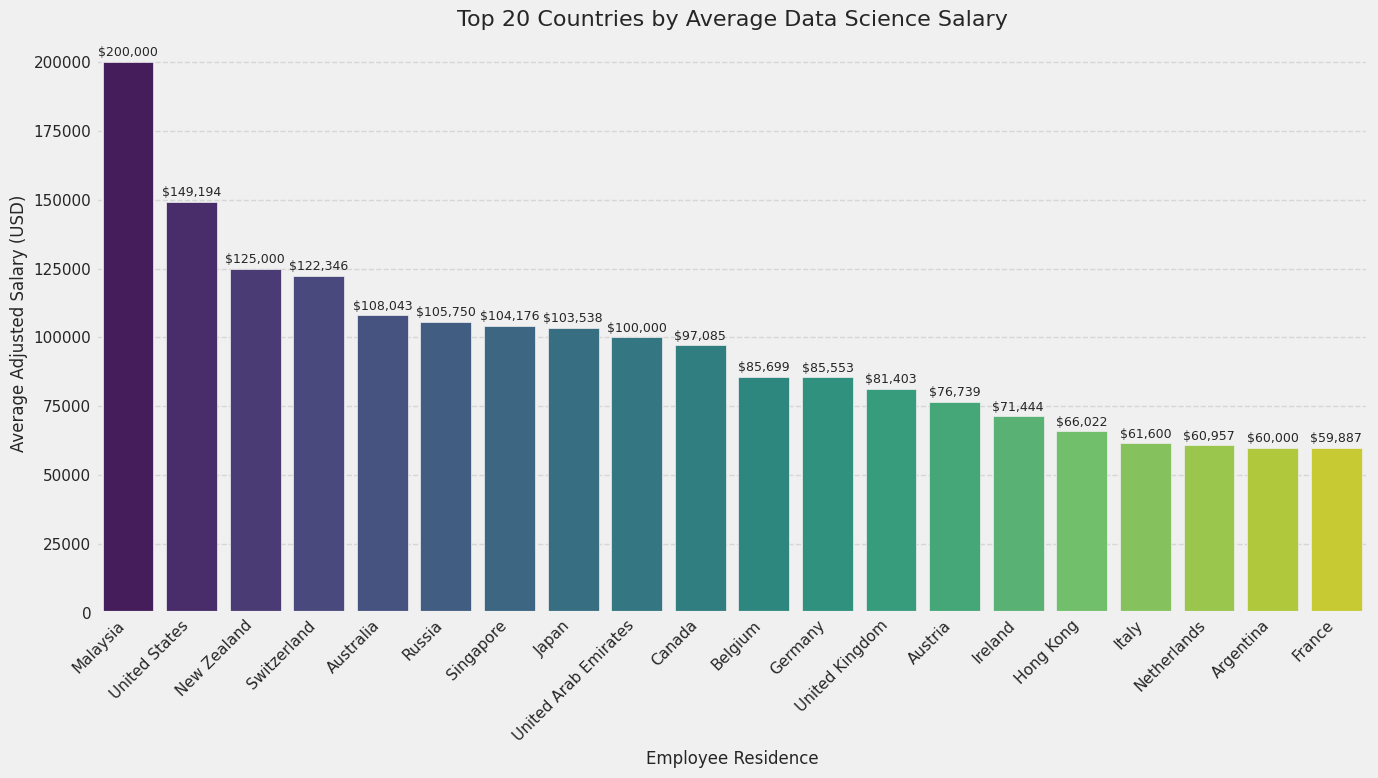

In [ ]:
df['adjusted_salary'] = df['salary_in_usd']

# Create mapping from ISO-2 to country names for visualization
iso2_to_name = {
    'US': 'United States', 'GB': 'United Kingdom', 'DE': 'Germany', 'FR': 'France',
    'CA': 'Canada', 'IN': 'India', 'AU': 'Australia', 'ES': 'Spain', 'BR': 'Brazil',
    'NL': 'Netherlands', 'JP': 'Japan', 'CH': 'Switzerland', 'IT': 'Italy',
    'SG': 'Singapore', 'SE': 'Sweden', 'MX': 'Mexico', 'FI': 'Finland', 'DK': 'Denmark',
    'PL': 'Poland', 'PT': 'Portugal', 'NZ': 'New Zealand', 'IE': 'Ireland',
    'HK': 'Hong Kong', 'RU': 'Russia', 'BE': 'Belgium', 'IL': 'Israel',
    'UA': 'Ukraine', 'TR': 'Turkey', 'AE': 'United Arab Emirates', 'ZA': 'South Africa',
    'CO': 'Colombia', 'AR': 'Argentina', 'CL': 'Chile', 'AT': 'Austria', 'MY': 'Malaysia',
    'NG': 'Nigeria', 'VN': 'Vietnam', 'KR': 'South Korea', 'TH': 'Thailand'
}

# Calculate average salary by employee residence
avg_salary_by_residence = df.groupby('employee_residence')['adjusted_salary'].mean().reset_index()

# Add country names for mapping
avg_salary_by_residence['country_name'] = avg_salary_by_residence['employee_residence'].map(iso2_to_name)
avg_salary_by_residence = avg_salary_by_residence.dropna(subset=['country_name'])  # Drop unmapped countries

# Create the choropleth map
fig2 = px.choropleth(avg_salary_by_residence,
                     locations='country_name',
                     locationmode='country names',
                     color='adjusted_salary',
                     hover_name='country_name',
                     hover_data={'employee_residence': True, 'adjusted_salary': ':,.0f'},
                     color_continuous_scale=px.colors.sequential.Plasma,
                     title='Average Salary by Employee Residence',
                     labels={'adjusted_salary': 'Average Adjusted Salary'},
                     projection='natural earth')

fig2.update_layout(width=1000, height=600)
fig2.show()

# Create a sorted bar chart for top 20 countries
top_countries = avg_salary_by_residence.sort_values('adjusted_salary', ascending=False).head(20)

plt.figure(figsize=(14, 8))
chart = sns.barplot(x='country_name', y='adjusted_salary', data=top_countries,
                    palette='viridis', order=top_countries['country_name'])
plt.title('Top 20 Countries by Average Data Science Salary', fontsize=16)
plt.xlabel('Employee Residence', fontsize=12)
plt.ylabel('Average Adjusted Salary (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add salary values on top of bars
for i, bar in enumerate(chart.patches):
    chart.text(bar.get_x() + bar.get_width()/2.,
              bar.get_height() + 2000,
              f'${top_countries["adjusted_salary"].iloc[i]:,.0f}',
              ha='center', fontsize=9)

plt.tight_layout()
plt.show()

> *The US, Switzerland, and Israel lead in data science salaries. Interestingly, professionals working for companies outside their country of residence tend to earn more on average, highlighting the benefits of remote work arrangements with companies in high-paying markets.*

### 6. Remote Work Analysis

In [ ]:
# Salary by remote ratio
remote_salary = df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'median', 'count']).reset_index()
remote_salary['remote_ratio'] = remote_salary['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.bar(remote_salary, x='remote_ratio', y=['mean', 'median'],
            barmode='group', title='Salary by Remote Work Ratio',
            labels={'value': 'Salary (USD)', 'remote_ratio': 'Work Setting', 'variable': 'Metric'},
            color_discrete_sequence=['#2a9d8f', '#e76f51'])

fig.update_layout(width=800, height=500)
fig.show()

# Remote ratio trends over time
remote_time = df.groupby(['work_year', 'remote_ratio']).size().reset_index(name='count')
total_per_year = remote_time.groupby('work_year')['count'].sum().reset_index()
remote_time = remote_time.merge(total_per_year, on='work_year', suffixes=('', '_total'))
remote_time['percentage'] = (remote_time['count'] / remote_time['count_total']) * 100
remote_time['remote_ratio'] = remote_time['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.line(remote_time, x='work_year', y='percentage', color='remote_ratio',
             title='Remote Work Trends (2020-2025)',
             labels={'percentage': 'Percentage of Jobs', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

> *Fully remote positions tend to offer higher salaries on average. We can also observe a significant shift toward remote work after 2020 (likely due to the COVID-19 pandemic), with the trend stabilizing around 2023-2024 but still showing a higher remote work percentage compared to pre-2020 levels.*

### 7. Company Size Impact

In [ ]:
# Salary by company size
company_salary = df.groupby(['company_size', 'experience_level'])['salary_in_usd'].median().reset_index()
company_salary['company_size'] = company_salary['company_size'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})
company_salary['experience_level'] = company_salary['experience_level'].map({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.bar(company_salary, x='company_size', y='salary_in_usd', color='experience_level',
            barmode='group', title='Median Salary by Company Size and Experience Level',
            labels={'salary_in_usd': 'Median Salary (USD)', 'company_size': 'Company Size'},
            template='plotly_white')

fig.update_layout(width=900, height=500)
fig.show()

> *Larger companies generally offer higher salaries across all experience levels, with the gap most pronounced at the executive level. This reflects the greater resources and revenue of larger organizations.*

### 8. Currency Analysis

In [ ]:
# Top salary currencies
currency_counts = df['salary_currency'].value_counts().head(10)

fig = px.pie(values=currency_counts.values, names=currency_counts.index,
            title='Distribution of Salary Currencies',
            template='plotly_white')

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(width=700, height=500)
fig.show()

# Exchange rate analysis (implied from salary and salary_in_usd)
df['implied_exchange_rate'] = df['salary'] / df['salary_in_usd']
top_currencies = df['salary_currency'].value_counts().head(10).index.tolist()
exchange_rates = df[df['salary_currency'].isin(top_currencies)].groupby(['work_year', 'salary_currency'])['implied_exchange_rate'].median().reset_index()

fig = px.line(exchange_rates, x='work_year', y='implied_exchange_rate', color='salary_currency',
             title='Implied Exchange Rate Trends (2020-2025)',
             labels={'implied_exchange_rate': 'Rate vs USD', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

> *USD dominates as the primary currency for data science salaries globally. The exchange rate analysis shows relative currency strength over time, with some currencies showing depreciation against the USD.*

### 9. Correlation Analysis

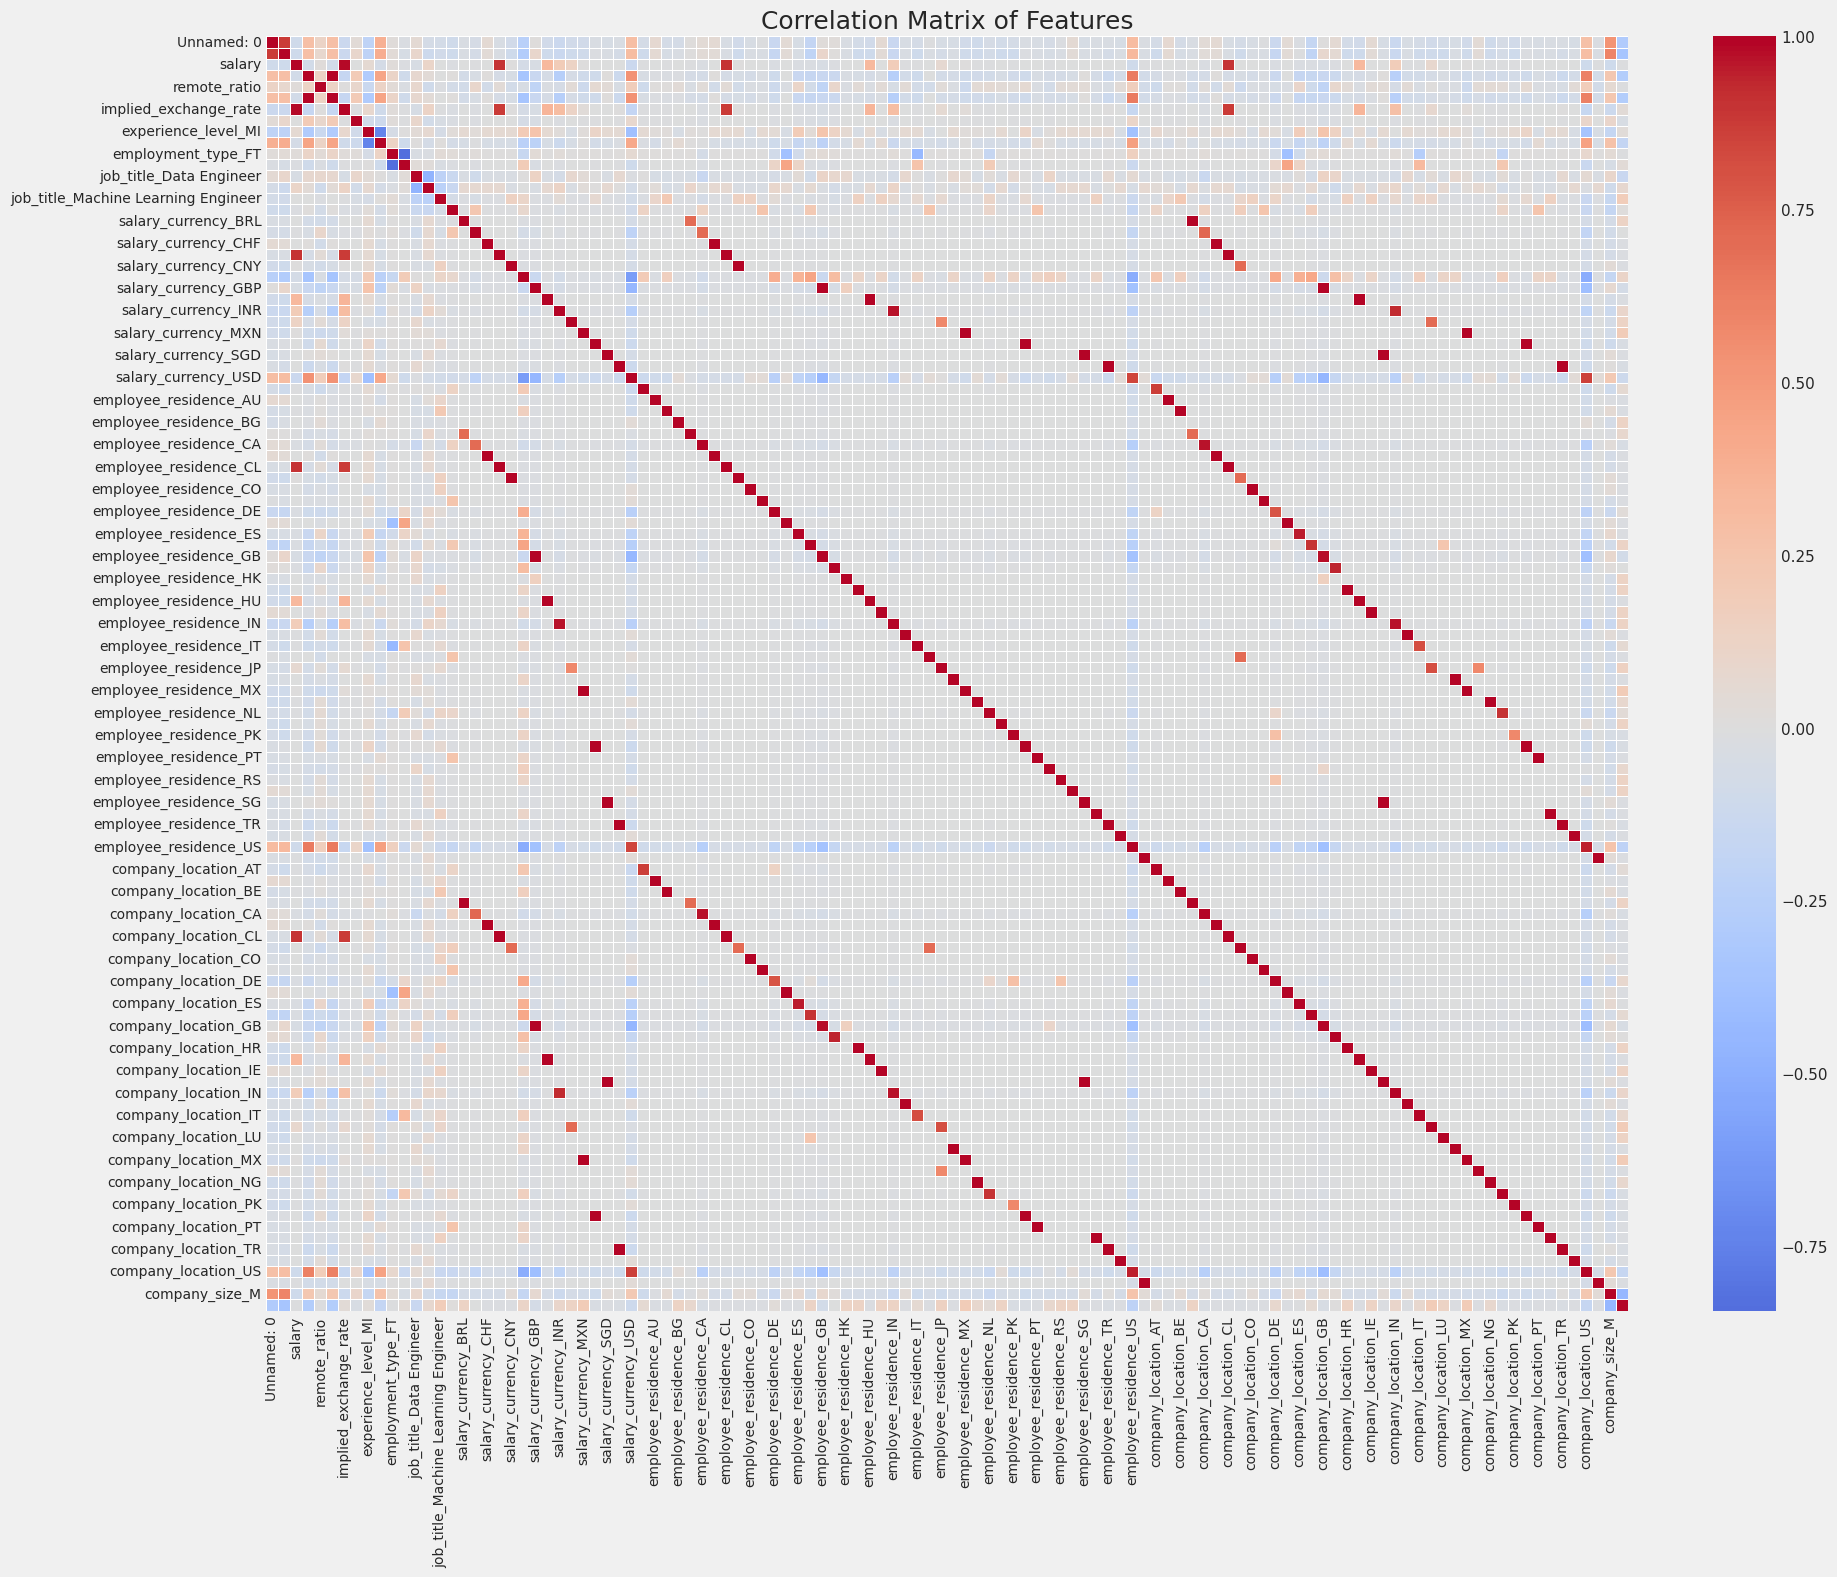

Top 10 features positively correlated with salary:
adjusted_salary          1.000000
salary_in_usd            1.000000
employee_residence_US    0.637475
company_location_US      0.604343
salary_currency_USD      0.537926
experience_level_SE      0.441240
work_year                0.280825
Unnamed: 0               0.280324
company_size_M           0.234185
experience_level_EX      0.196964
remote_ratio             0.121871
Name: salary_in_usd, dtype: float64

Top 10 features negatively correlated with salary:
company_location_FR     -0.149531
company_location_ES     -0.156063
implied_exchange_rate   -0.157414
employee_residence_FR   -0.159797
company_location_IN     -0.244889
salary_currency_INR     -0.248065
employee_residence_IN   -0.258358
company_size_S          -0.274607
experience_level_MI     -0.295622
salary_currency_EUR     -0.344150
Name: salary_in_usd, dtype: float64


In [ ]:
# Create dummy variables for categorical features
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'salary_currency',
                    'employee_residence', 'company_location', 'company_size']
numerical_cols = ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

# Select top job titles for simplified correlation analysis
top_job_titles = df['job_title'].value_counts().head(5).index.tolist()
df_corr = df[df['job_title'].isin(top_job_titles)].copy()

# Create dummy variables
df_dummies = pd.get_dummies(df_corr, columns=categorical_cols, drop_first=True)

# Calculate and plot correlation matrix
corr_matrix = df_dummies.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=18)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Key salary correlations
salary_corr = corr_matrix['salary_in_usd'].sort_values(ascending=False)
print("Top 10 features positively correlated with salary:")
print(salary_corr.head(11))  # Including salary_in_usd itself
print("\nTop 10 features negatively correlated with salary:")
print(salary_corr.tail(10))

> *The correlation analysis reveals strong relationships between salary and factors like experience level, company size, and certain job titles. We can use these insights for feature selection in our models.*

##  Conclusion and Key Insights

Our comprehensive analysis of the data science salary dataset has yielded several valuable insights:

1. **Salary Determinants**: Experience level, company location, and job category are the strongest predictors of salary in the data science field. Executive positions command significantly higher salaries than other levels.

2. **Geographic Impact**: The US, Switzerland, and Israel consistently offer the highest salaries. There's a substantial gap between top-paying countries and emerging tech markets.

3. **Remote Work Premium**: Fully remote positions tend to offer higher salaries on average, potentially reflecting the global competition for talent regardless of location.

4. **Career Growth**: The transition from Senior to Executive level shows the largest percentage increase in salary, highlighting the significant premium placed on leadership skills.

5. **Job Title Differentiation**: Machine Learning Engineers and Research Scientists command higher salaries than Data Analysts and general Software Engineers, reflecting the specialized skills required.

6. **Company Size Effect**: Larger companies generally offer higher compensation across all experience levels, with the gap most pronounced at the executive level.
